# Inteligência Artificial Aplicada na Análise da Desigualdade Econômica e Pobreza Global

**Autores:** Guilherme Henrique de Souza Sonsin, João Victor da Silva Pires, Ricardo Henrique Vinciguerra, Stefany Kazik Sarmento Bassi  
**Instituição:** Centro Universitário Assis Gurgacz — Toledo/PR — Brasil  
**Dataset:** *Global Poverty and Economic Inequality (2015–2024)* — Kaggle  

## Célula 1 — Instalação de Dependências

In [1]:
import subprocess
import sys

def ensure_package(package_name):
    try:
        __import__(package_name)
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

ensure_package('kagglehub')
ensure_package('openpyxl')

## Célula 2 — Importação das Bibliotecas

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
from IPython.display import display

import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

## Seção 1 — Download e Leitura do Dataset

A obtenção dos dados foi realizada de forma automatizada por meio do site Kaggle, utilizando a biblioteca `kagglehub`. Em caso de falha (sem conexão ou credenciais), o código busca o arquivo CSV na pasta local do notebook.

In [3]:
DATASET_REF = 'hamnamunir/global-poverty-and-economic-inequality-2015-2024'
EXPECTED_CSV = 'global_poverty_economic_inequality.csv'

df = None
data_file = None

# 1) Tentar via KaggleHub
try:
    kaggle_path = Path(kagglehub.dataset_download(DATASET_REF))
    print('Diretório do KaggleHub:', kaggle_path)
    csv_path = kaggle_path / EXPECTED_CSV
    if csv_path.exists():
        data_file = csv_path
    else:
        csvs = list(kaggle_path.glob('*.csv'))
        if csvs:
            data_file = max(csvs, key=lambda f: f.stat().st_size)
except Exception as exc:
    print(f'Aviso: KaggleHub não disponível. Motivo: {exc}')

# 2) Fallback local
if data_file is None:
    for search_dir in [Path.cwd(), Path('/content')]:
        if not search_dir.exists():
            continue
        candidate = search_dir / EXPECTED_CSV
        if candidate.exists():
            data_file = candidate
            break
        csvs = list(search_dir.glob('*.csv'))
        if csvs:
            data_file = max(csvs, key=lambda f: f.stat().st_size)
            break

if data_file is None:
    raise RuntimeError(
        'Nenhum arquivo CSV encontrado.\n'
        'Configure suas credenciais do Kaggle ou coloque o arquivo CSV na mesma pasta do notebook.'
    )

print(f'Arquivo selecionado: {data_file}')
df = pd.read_csv(data_file)
print(f'Dimensão do dataset: {df.shape}')
df.head()

Diretório do KaggleHub: C:\Users\Guilherme Sonsin\.cache\kagglehub\datasets\hamnamunir\global-poverty-and-economic-inequality-2015-2024\versions\1
Arquivo selecionado: C:\Users\Guilherme Sonsin\.cache\kagglehub\datasets\hamnamunir\global-poverty-and-economic-inequality-2015-2024\versions\1\global_poverty_economic_inequality.csv
Dimensão do dataset: (10000, 25)


,record_id,year,country,region,income_group,gdp_per_capita_usd,poverty_rate_pct,gini_coefficient,hdi_score,unemployment_rate_pct,...,clean_water_access_pct,internet_penetration_pct,female_labor_participation_pct,social_protection_coverage_pct,income_share_top10_pct,income_share_bottom40_pct,urban_population_pct,remittances_pct_of_gdp,foreign_aid_million_usd,co2_per_capita_tonnes
0,POV0000001,2017,Bangladesh,South Asia,Lower-Middle Income,2985,23.19,39.22,0.692,5.46,...,86.1,60.7,13.3,40.0,46.5,10.5,58.4,5.8,124,1.78
1,POV0000002,2017,Cambodia,Southeast Asia,Lower-Middle Income,1651,36.72,34.04,0.690,7.01,...,85.1,39.9,44.8,43.1,47.9,17.7,34.4,12.8,28,1.49
2,POV0000003,2019,Tanzania,Sub-Saharan Africa,Low Income,1396,72.25,40.07,0.515,5.13,...,54.0,30.6,74.9,14.0,27.0,8.0,37.7,15.5,257,0.54
3,POV0000004,2022,Myanmar,Southeast Asia,Lower-Middle Income,1304,14.46,36.31,0.661,11.96,...,71.7,34.0,59.8,44.7,55.0,16.8,44.4,7.8,196,1.00
4,POV0000005,2017,Tanzania,Sub-Saharan Africa,Low Income,1290,41.03,44.10,0.412,6.98,...,55.2,10.5,54.3,24.7,45.2,15.6,25.5,24.6,946,0.49


## Seção 2 — Pré-processamento

### 3.3.1 Renomeação de Variáveis
Todas as colunas foram renomeadas do inglês para o português, utilizando um dicionário de mapeamento explícito.

In [4]:
RENOMEAR = {
    'record_id':                       'id_registro',
    'year':                            'ano',
    'country':                         'pais',
    'region':                          'regiao',
    'income_group':                    'grupo_renda',
    'gdp_per_capita_usd':              'pib_per_capita_usd',
    'poverty_rate_pct':                'taxa_pobreza_pct',
    'gini_coefficient':                'coef_gini',
    'hdi_score':                       'indice_idh',
    'unemployment_rate_pct':           'taxa_desemprego_pct',
    'inflation_rate_pct':              'taxa_inflacao_pct',
    'literacy_rate_pct':               'taxa_alfabetizacao_pct',
    'life_expectancy_years':           'expectativa_vida_anos',
    'child_mortality_per_1000':        'mortalidade_infantil_por_1000',
    'electricity_access_pct':          'acesso_eletricidade_pct',
    'clean_water_access_pct':          'acesso_agua_limpa_pct',
    'internet_penetration_pct':        'penetracao_internet_pct',
    'female_labor_participation_pct':  'participacao_feminina_trabalho_pct',
    'social_protection_coverage_pct':  'cobertura_protecao_social_pct',
    'income_share_top10_pct':          'renda_top10_pct',
    'income_share_bottom40_pct':       'renda_bottom40_pct',
    'urban_population_pct':            'populacao_urbana_pct',
    'remittances_pct_of_gdp':          'remessas_pct_pib',
    'foreign_aid_million_usd':         'ajuda_externa_milhoes_usd',
    'co2_per_capita_tonnes':           'co2_per_capita_toneladas'
}

df = df.rename(columns={k: v for k, v in RENOMEAR.items() if k in df.columns})
print('Colunas renomeadas com sucesso!')
print(f'Total de colunas: {len(df.columns)}')

Colunas renomeadas com sucesso!
Total de colunas: 25


### 3.3.2 Padronização, Filtro Temporal e Diagnóstico de Dados Ausentes

In [5]:
# Constantes de referência
COL_ANO      = 'ano'
COL_PAIS     = 'pais'
COL_REGIAO   = 'regiao'
COL_POBREZA  = 'taxa_pobreza_pct'
COL_GINI     = 'coef_gini'
COL_PIB      = 'pib_per_capita_usd'
COL_IDH      = 'indice_idh'
COL_DESEMP   = 'taxa_desemprego_pct'

# Filtro temporal 2015-2024
df = df[df[COL_ANO].between(2015, 2024)].copy()

# Coerção para tipos numéricos
colunas_numericas = [c for c in df.columns if c not in ['id_registro', 'ano', 'pais', 'regiao', 'grupo_renda']]
for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset filtrado: {len(df)} registros, período {df[COL_ANO].min()} a {df[COL_ANO].max()}')
print(f'Colunas numéricas para análise: {len(colunas_numericas)}')

# Diagnóstico de dados ausentes
ausentes = df[colunas_numericas].isnull().mean().mul(100).round(2)
ausentes_relevantes = ausentes[ausentes > 0]
if ausentes_relevantes.empty:
    print('\nNenhum dado ausente detectado nas colunas numéricas.')
else:
    print('\nPercentual de dados ausentes:')
    print(ausentes_relevantes)

Dataset filtrado: 10000 registros, período 2015 a 2024
Colunas numéricas para análise: 20

Nenhum dado ausente detectado nas colunas numéricas.


## Seção 3 — Análise Exploratória dos Dados (EDA)

### Estatísticas Descritivas

Cálculo de média, desvio padrão, mínimo, máximo e quartis para os principais indicadores socioeconômicos.

In [6]:
indicadores_principais = [COL_POBREZA, COL_GINI, COL_PIB, COL_IDH, COL_DESEMP]
display(df[indicadores_principais].describe().round(2))

,taxa_pobreza_pct,coef_gini,pib_per_capita_usd,indice_idh,taxa_desemprego_pct
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,22.88,42.14,13365.29,0.66,8.97
std,20.62,7.63,22003.61,0.16,3.77
min,0.50,20.30,470.00,0.35,-1.02
25%,4.79,36.74,1518.00,0.54,6.12
50%,16.98,42.08,2920.00,0.65,8.64
75%,35.69,47.91,11478.25,0.76,11.53
max,74.87,63.51,107221.00,0.99,21.31


### Tendências Temporais (2015–2024)

Médias anuais globais dos indicadores prioritários: taxa de pobreza, coeficiente de Gini, PIB per capita, taxa de desemprego e IDH.

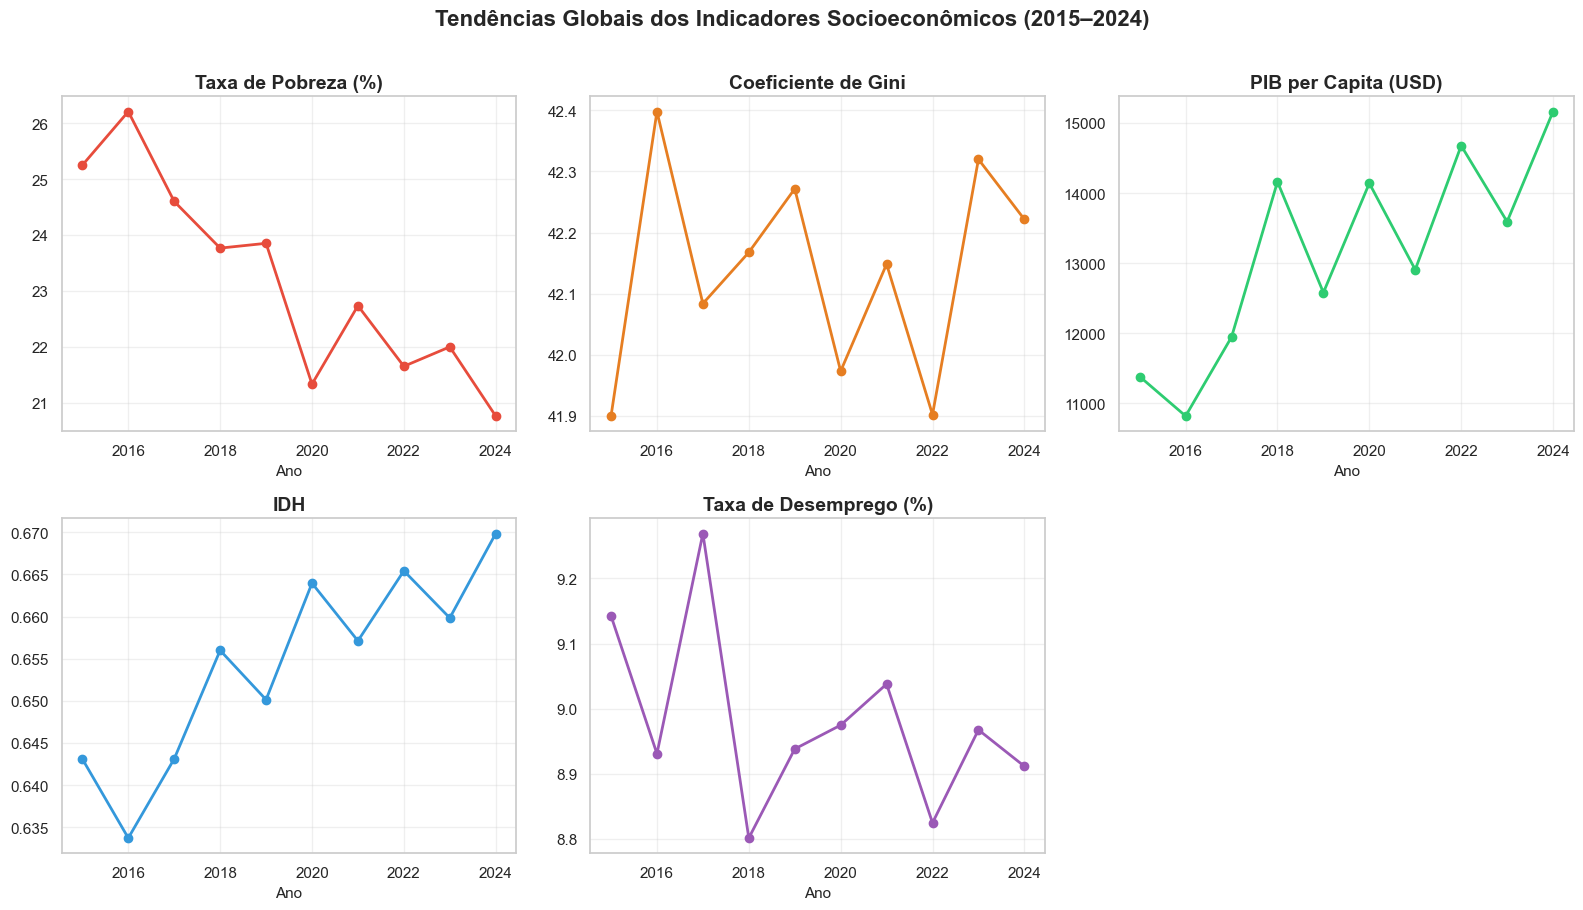

In [7]:
tendencias = df.groupby(COL_ANO)[indicadores_principais].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
titulos = ['Taxa de Pobreza (%)', 'Coeficiente de Gini', 'PIB per Capita (USD)', 'IDH', 'Taxa de Desemprego (%)']
cores = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

for i, (col, titulo, cor) in enumerate(zip(indicadores_principais, titulos, cores)):
    ax = axes[i // 3][i % 3]
    ax.plot(tendencias.index, tendencias[col], marker='o', color=cor, linewidth=2)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.grid(True, alpha=0.3)

axes[1][2].set_visible(False)
fig.suptitle('Tendências Globais dos Indicadores Socioeconômicos (2015–2024)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Comparação entre Países

Identificação dos 10 países com maiores e menores taxas médias de pobreza e coeficiente de Gini.

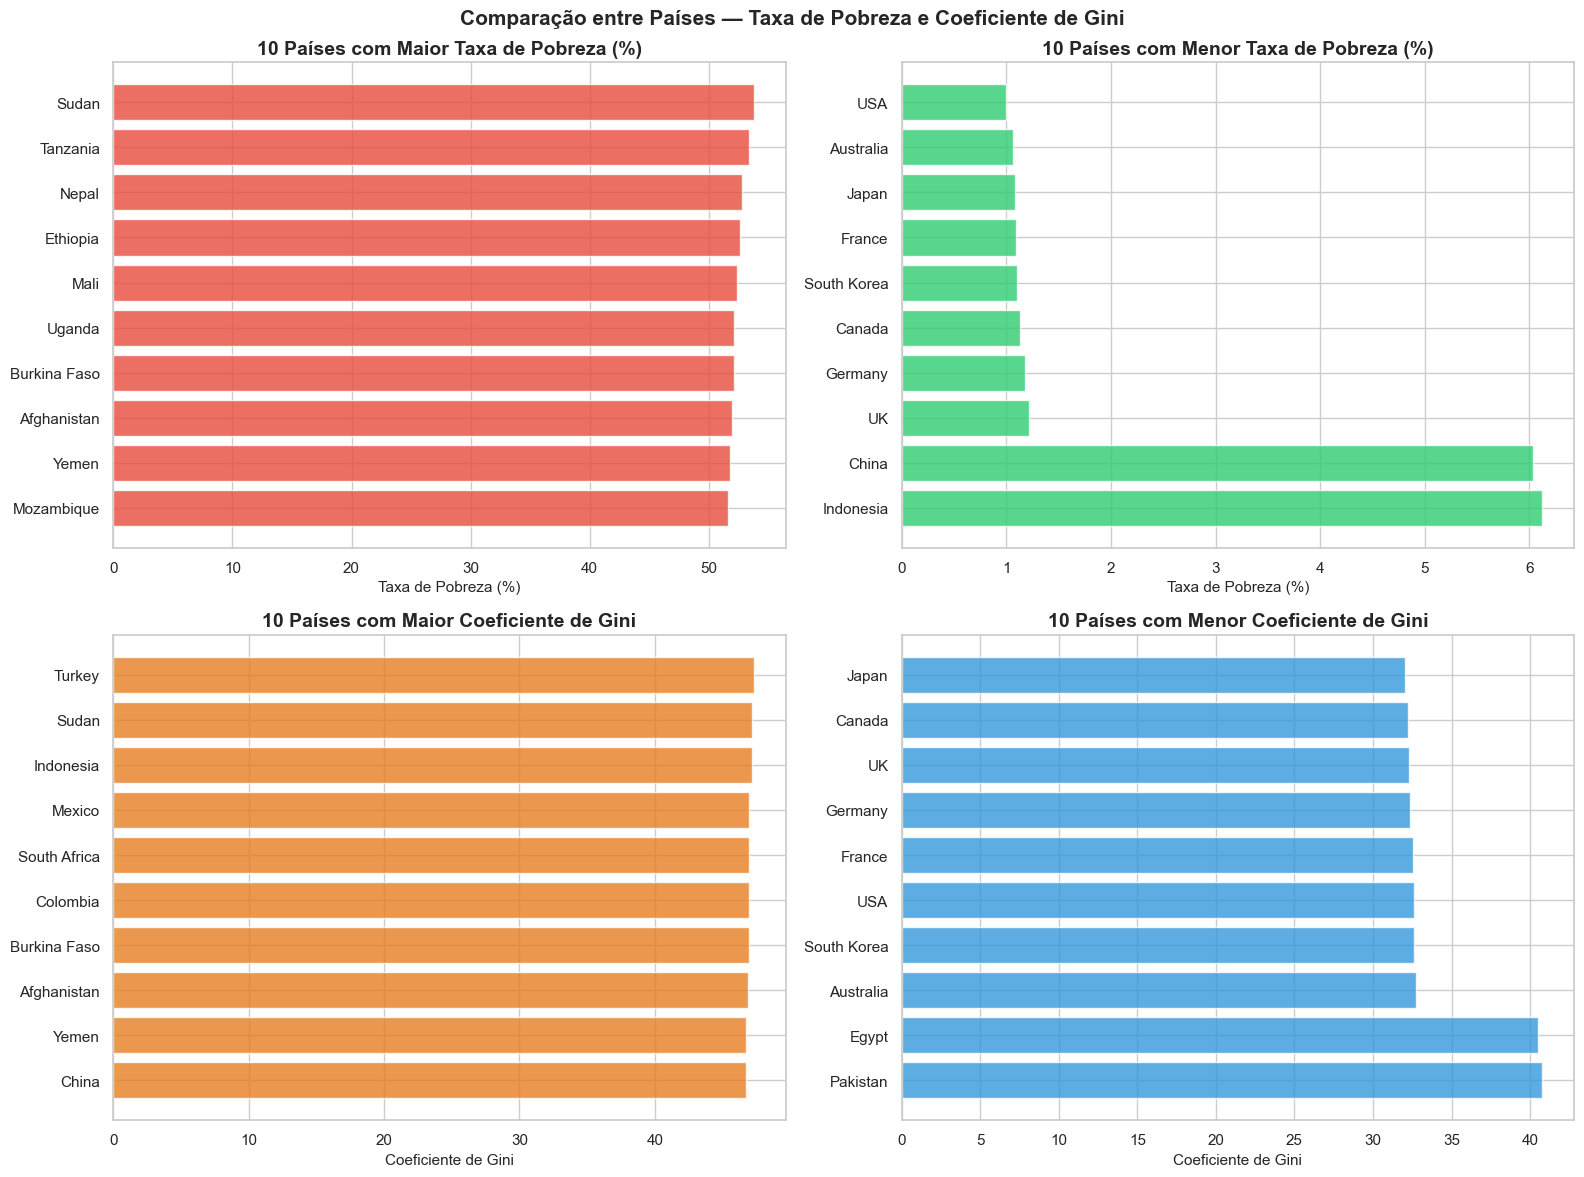

In [8]:
media_pais = df.groupby(COL_PAIS)[[COL_POBREZA, COL_GINI]].mean().round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Taxa de Pobreza — Top 10 maiores
top10_pob = media_pais[COL_POBREZA].nlargest(10).sort_values()
axes[0][0].barh(top10_pob.index, top10_pob.values, color='#e74c3c', alpha=0.8)
axes[0][0].set_title('10 Países com Maior Taxa de Pobreza (%)', fontweight='bold')
axes[0][0].set_xlabel('Taxa de Pobreza (%)')

# Taxa de Pobreza — Top 10 menores
bot10_pob = media_pais[COL_POBREZA].nsmallest(10).sort_values(ascending=False)
axes[0][1].barh(bot10_pob.index, bot10_pob.values, color='#2ecc71', alpha=0.8)
axes[0][1].set_title('10 Países com Menor Taxa de Pobreza (%)', fontweight='bold')
axes[0][1].set_xlabel('Taxa de Pobreza (%)')

# Gini — Top 10 maiores
top10_gini = media_pais[COL_GINI].nlargest(10).sort_values()
axes[1][0].barh(top10_gini.index, top10_gini.values, color='#e67e22', alpha=0.8)
axes[1][0].set_title('10 Países com Maior Coeficiente de Gini', fontweight='bold')
axes[1][0].set_xlabel('Coeficiente de Gini')

# Gini — Top 10 menores
bot10_gini = media_pais[COL_GINI].nsmallest(10).sort_values(ascending=False)
axes[1][1].barh(bot10_gini.index, bot10_gini.values, color='#3498db', alpha=0.8)
axes[1][1].set_title('10 Países com Menor Coeficiente de Gini', fontweight='bold')
axes[1][1].set_xlabel('Coeficiente de Gini')

plt.suptitle('Comparação entre Países — Taxa de Pobreza e Coeficiente de Gini', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de Correlação

Análise das correlações entre os principais indicadores socioeconômicos.

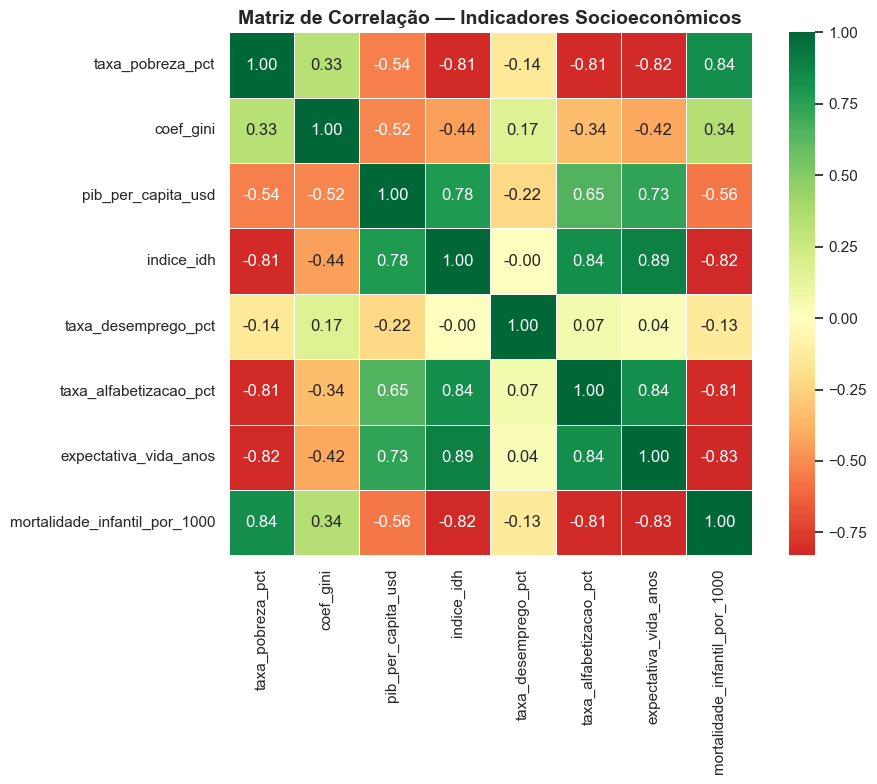

In [9]:
corr_cols = [COL_POBREZA, COL_GINI, COL_PIB, COL_IDH, COL_DESEMP,
             'taxa_alfabetizacao_pct', 'expectativa_vida_anos', 'mortalidade_infantil_por_1000']

corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação — Indicadores Socioeconômicos', fontweight='bold')
plt.tight_layout()
plt.show()

## Seção 4 — Aprendizado Não Supervisionado: K-Means

A clusterização K-Means foi utilizada para agrupar países com perfis socioeconômicos semelhantes, sem recorrer a classificações prévias.

**Procedimento:**
1. Cálculo das médias por país para todas as variáveis numéricas;
2. Padronização das features utilizando StandardScaler;
3. Aplicação do K-Means com k=4 clusters, n_init=10 e random_state=42;
4. Visualização dos clusters em gráfico de dispersão bidimensional (PIB per capita × taxa de pobreza).

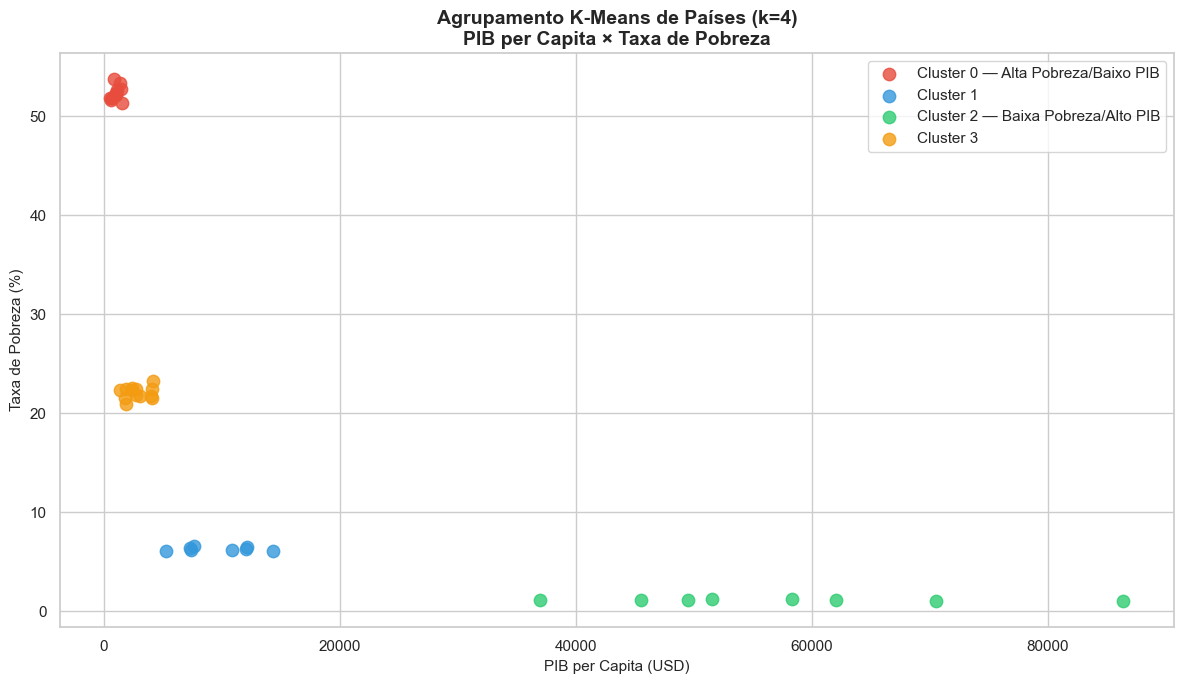


Distribuição de países por cluster:
cluster
0    11
1     8
2     8
3    13
Name: count, dtype: int64


In [10]:
# Médias por país
media_pais_num = df.groupby(COL_PAIS)[colunas_numericas].mean()

# Imputação de NaN antes do scaler
imputer = SimpleImputer(strategy='mean')
X_imp = imputer.fit_transform(media_pais_num)

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# K-Means
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
media_pais_num = media_pais_num.copy()
media_pais_num['cluster'] = kmeans.fit_predict(X_scaled)

# Visualização
plt.figure(figsize=(12, 7))
cores_cluster = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12'}
labels_cluster = {0: 'Cluster 0 — Alta Pobreza/Baixo PIB', 1: 'Cluster 1',
                  2: 'Cluster 2 — Baixa Pobreza/Alto PIB', 3: 'Cluster 3'}

for c in range(4):
    mask = media_pais_num['cluster'] == c
    plt.scatter(
        media_pais_num.loc[mask, COL_PIB],
        media_pais_num.loc[mask, COL_POBREZA],
        c=cores_cluster[c], label=labels_cluster[c], s=80, alpha=0.8
    )

plt.title('Agrupamento K-Means de Países (k=4)\nPIB per Capita × Taxa de Pobreza', fontweight='bold')
plt.xlabel('PIB per Capita (USD)')
plt.ylabel('Taxa de Pobreza (%)')
plt.legend()
plt.tight_layout()
plt.show()

print('\nDistribuição de países por cluster:')
print(media_pais_num['cluster'].value_counts().sort_index())

## Seção 5 — Aprendizado Supervisionado: Modelos de Regressão

Três modelos de regressão foram avaliados por validação cruzada K-Fold (k=5) para duas variáveis-alvo:
- **Taxa de Pobreza (%)**
- **Coeficiente de Gini**

**Modelos avaliados:**
- **Regressão Linear:** modelo baseline que assume relações lineares;
- **Random Forest Regressor:** ensemble de árvores de decisão que captura relações não lineares;
- **Gradient Boosting Regressor:** método de boosting sequencial que otimiza o erro residual a cada iteração.

**Métricas:** MAE (Erro Absoluto Médio), RMSE (Raiz do Erro Quadrático Médio), R² (Coeficiente de Determinação).

In [11]:
MODELOS = {
    'Regressão Linear':      LinearRegression(),
    'Random Forest':         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=100, random_state=42)
}

TARGETS = [COL_POBREZA, COL_GINI]
TARGETS_LABEL = {'taxa_pobreza_pct': 'Taxa de Pobreza (%)', 'coef_gini': 'Coeficiente de Gini'}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}

for target in TARGETS:
    print(f'\n--- Variável-alvo: {TARGETS_LABEL[target]} ---')
    df_modelo = df[colunas_numericas].copy()

    if target not in df_modelo.columns:
        print(f'Coluna {target} não encontrada. Pulando.')
        continue

    y = df_modelo[target]
    X = df_modelo.drop(columns=[target])

    mask = y.notna()
    X, y = X[mask], y[mask]

    resultados[target] = {}

    for nome, modelo in MODELOS.items():
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('model', modelo)
        ])
        cv = cross_validate(
            pipe, X, y, cv=kf,
            scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'],
            return_train_score=False
        )
        mae  = -cv['test_neg_mean_absolute_error'].mean()
        rmse = -cv['test_neg_root_mean_squared_error'].mean()
        r2   = cv['test_r2'].mean()
        resultados[target][nome] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
        print(f'  {nome}: MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}')

print('\nAvaliação concluída.')


--- Variável-alvo: Taxa de Pobreza (%) ---
  Regressão Linear: MAE=6.708 | RMSE=8.824 | R²=0.817
  Random Forest: MAE=6.173 | RMSE=8.255 | R²=0.839
  Gradient Boosting: MAE=6.178 | RMSE=8.238 | R²=0.840

--- Variável-alvo: Coeficiente de Gini ---
  Regressão Linear: MAE=5.246 | RMSE=6.364 | R²=0.304
  Random Forest: MAE=4.869 | RMSE=5.814 | R²=0.419
  Gradient Boosting: MAE=4.838 | RMSE=5.769 | R²=0.428

Avaliação concluída.


## Seção 6 — Resultados e Discussão

Após o treinamento dos modelos, as métricas de desempenho foram calculadas para avaliar a qualidade das previsões realizadas. Os resultados são apresentados abaixo de forma comparativa.


=== Taxa de Pobreza (%) ===


,MAE,RMSE,R²
Regressão Linear,6.708,8.824,0.817
Random Forest,6.173,8.255,0.839
Gradient Boosting,6.178,8.238,0.840


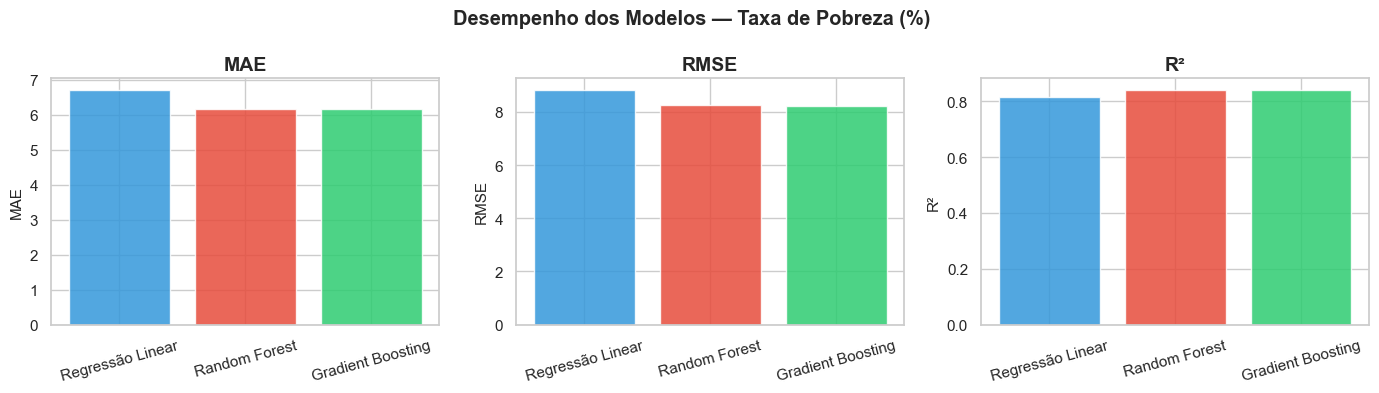


=== Coeficiente de Gini ===


,MAE,RMSE,R²
Regressão Linear,5.246,6.364,0.304
Random Forest,4.869,5.814,0.419
Gradient Boosting,4.838,5.769,0.428


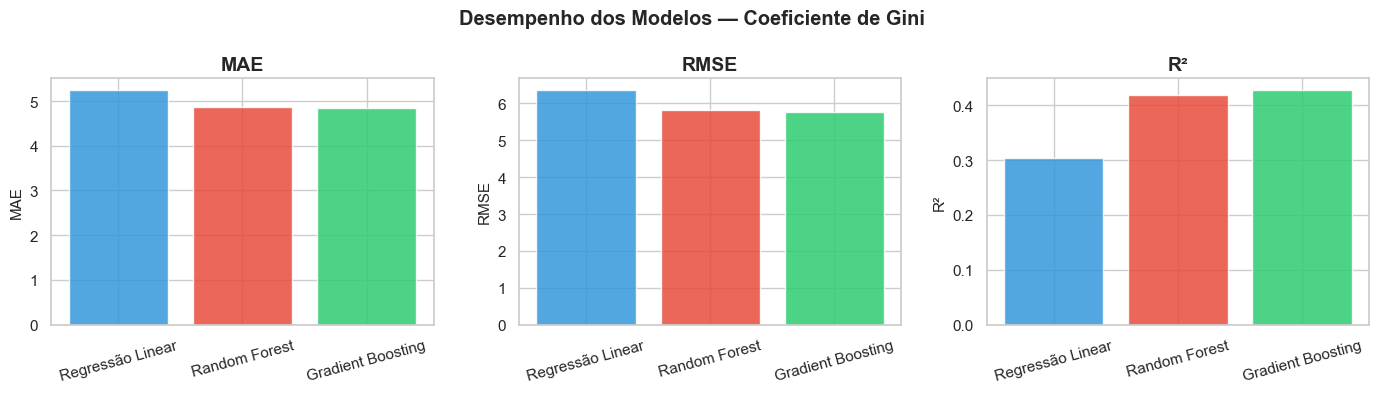

In [12]:
for target, res in resultados.items():
    df_res = pd.DataFrame(res).T.round(3)
    print(f'\n=== {TARGETS_LABEL[target]} ===')
    display(df_res)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    metricas = ['MAE', 'RMSE', 'R²']
    cores_mod = ['#3498db', '#e74c3c', '#2ecc71']

    for j, metrica in enumerate(metricas):
        valores = [res[m][metrica] for m in res]
        axes[j].bar(list(res.keys()), valores, color=cores_mod, alpha=0.85)
        axes[j].set_title(metrica, fontweight='bold')
        axes[j].set_ylabel(metrica)
        axes[j].tick_params(axis='x', rotation=15)

    fig.suptitle(f'Desempenho dos Modelos — {TARGETS_LABEL[target]}', fontweight='bold')
    plt.tight_layout()
    plt.show()

### Discussão dos Resultados

Os resultados demonstraram que os **modelos baseados em árvores (Random Forest e Gradient Boosting)** apresentaram desempenho superior em comparação à regressão linear tradicional, evidenciando a presença de **relações não lineares** entre os indicadores econômicos e sociais analisados.

A análise das variáveis mais relevantes mostrou que fatores relacionados à **renda, emprego e desenvolvimento econômico** apresentaram forte influência sobre os níveis de pobreza observados.

Além disso, os gráficos gerados durante a análise exploratória evidenciaram padrões consistentes entre os países analisados, demonstrando que indicadores econômicos possuem impacto significativo sobre os índices de desigualdade social.

Os resultados obtidos reforçam a importância da utilização de técnicas de Inteligência Artificial para apoiar estudos socioeconômicos e subsidiar decisões relacionadas à formulação de políticas públicas.